# 🏫 School Infrastructure Priority: ML for Education Facility Planning

**Author:** Dean | Lead Data & AI Engineer

**Government:** Dept of Education, ACARA, State Education Depts, Infrastructure Australia

Dataset: sklearn synthetic regression — NO dataset needed.

---

Generated: (2000, 12)
count    2000.000000
mean       -4.764695
std       157.370777
min      -528.173624
25%      -108.937859
50%        -5.940017
75%        99.329981
max       538.330072
Name: upgrade_priority_score, dtype: float64


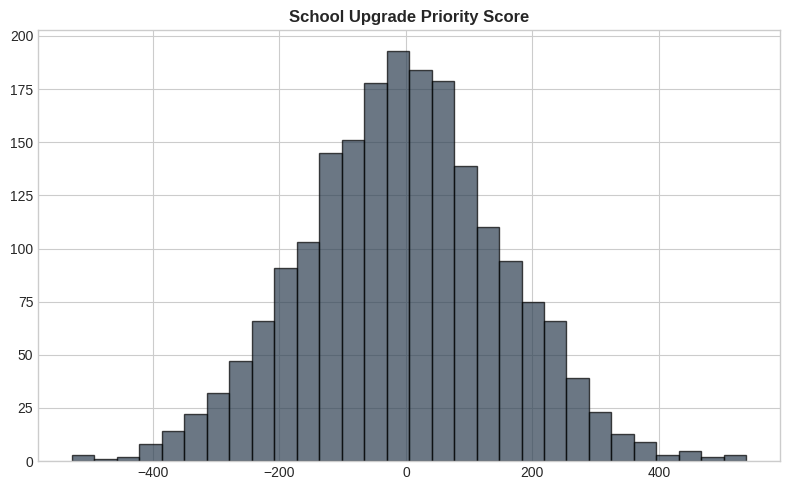

AU: 9,600+ schools. $20B+ school infrastructure pipeline. ACARA manages NAPLAN & ICSEA.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_regression(n_samples=2000,n_features=11,n_informative=8,noise=16,random_state=96)
names=['building_age_years','student_enrolment','enrolment_growth_5yr','maintenance_backlog_M','icsea_score','disability_access_rating','stem_facility_quality','sports_facility_rating','population_growth_area','land_size_ha','distance_to_nearest_school_km']
df=pd.DataFrame(X_arr,columns=names);df['upgrade_priority_score']=y;tc='upgrade_priority_score'
print(f"Generated: {df.shape}");print(df[tc].describe())
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(df[tc],bins=30,color='#2c3e50',edgecolor='black',alpha=0.7)
ax.set_title('School Upgrade Priority Score',fontweight='bold')
plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: 9,600+ schools. $20B+ school infrastructure pipeline. ACARA manages NAPLAN & ICSEA.")

Ridge: RMSE=16.19 MAE=13.01 R2=0.9894
RF: RMSE=61.17 MAE=46.99 R2=0.8486
XGB: RMSE=50.43 MAE=39.36 R2=0.8972
LGBM: RMSE=39.72 MAE=30.44 R2=0.9362
Best: Ridge


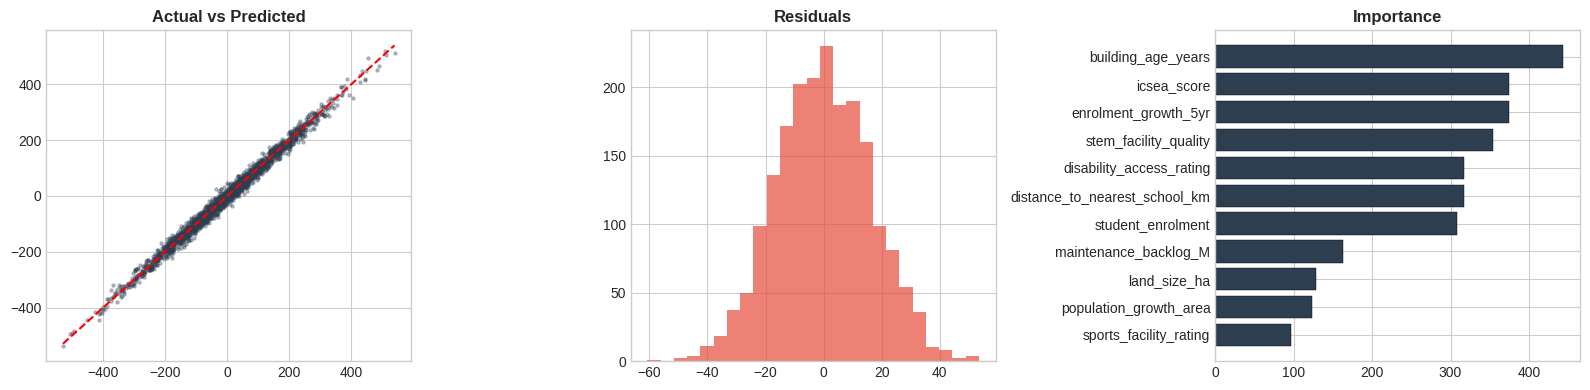

DEPLOYMENT: Ridge R2=0.9894 | State education asset data -> Infrastructure Australia priority list


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fr,fm,f2=[],[],[];fp=np.zeros(len(y2))
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        fr.append(np.sqrt(mean_squared_error(y2[vi],yp)));fm.append(mean_absolute_error(y2[vi],yp));f2.append(r2_score(y2[vi],yp))
    results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'preds':fp}
    print(f"{mn}: RMSE={np.mean(fr):.2f} MAE={np.mean(fm):.2f} R2={np.mean(f2):.4f}")
best=max(results,key=lambda k:results[k]['r2']);print(f"Best: {best}")
bp=results[best]['preds']
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].scatter(y2,bp,alpha=0.3,s=5,color='#2c3e50');axes[0].plot([y2.min(),y2.max()],[y2.min(),y2.max()],'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(y2-bp,bins=25,color='#e74c3c',alpha=0.7);axes[1].set_title('Residuals',fontweight='bold')
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi2=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[2].barh(fi2['Feature'],fi2['Imp'],color='#2c3e50',edgecolor='black',linewidth=0.3);axes[2].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
br=results[best];print(f"DEPLOYMENT: {best} R2={br['r2']:.4f} | State education asset data -> Infrastructure Australia priority list")